# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LeylaAghayeva1/ml-search-engineering/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question

Can a machine learning model identify content pages that are likely to decline in search performance more accurately than a simple rule-based baseline?

Decision it Supports

The goal is to help content teams prioritize which pages should be reviewed first for a potential content refresh. The model is intended to support human decision-making by producing a ranked review queue rather than automatically deciding which pages should be updated.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


df = pd.read_csv(
    "../../data/raw/content_refresh_anonymized.csv"
)
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)
features = [
    "search_volume",
    "competition",
    "word_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]
X = df[features].copy()
y = df["is_declining_label"]
groups = df["client_id"]
print("Features:", X.shape)
print("Label distribution:")
print(y.value_counts())

Features: (30000, 10)
Label distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the FlyRank Machine Learning Internship dataset, which contains approximately 30,000 anonymized content records with 44 features describing content characteristics and search performance.

The dataset includes features such as search volume, impressions, average position, click-through rate, content age, word count, competition, and days since the last update.

The target label was created by identifying pages with a downward trend in search performance.

To prevent information leakage, trend_direction and trend_pct were excluded because they directly determine the target label. Identifier columns such as content_id and client_id were also removed because they do not contribute useful predictive information.

All data is anonymized and contains no client names, URLs, or search queries.

In [6]:
df.shape
df.columns.tolist()
df["trend_direction"].value_counts()

trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

A rule-based baseline and a Logistic Regression model were developed and compared.

The baseline ranks pages using content freshness together with search demand and visibility signals.

The Logistic Regression model predicts the probability that a page belongs to the declining class using numerical search and content features, including:

search_volume
impressions_90d
ctr
avg_position
word_count
content_age_days
days_since_last_update
competition

The target label represents pages classified as declining.

Before training, leakage-prone variables (trend_direction and trend_pct) and identifier columns were removed.

Both approaches were evaluated using the same validation split and compared with Precision@20 and Precision@50, allowing an honest comparison of ranking quality.

In [17]:
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

df["is_declining_label"].value_counts()

is_declining_label
1    16262
0    13738
Name: count, dtype: int64

In [14]:
feature_columns = [
    "search_volume",
    "impressions_90d",
    "ctr",
    "avg_position",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "competition"
]

X = df[feature_columns]
y = df["is_declining_label"]

In [15]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=df["client_id"]
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)

,steps,"[('imputer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,penalty,'l2'


In [20]:
test_results = X_test.copy()

test_results["model_score"] = model.predict_proba(
    X_test
)[:,1]

test_results["actual"] = y_test.values

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Logistic Regression model outperformed the rule-based baseline on both evaluation metrics.

Metric	Baseline	Logistic Regression
Precision@20	0.50	0.75
Precision@50	0.46	0.58

The model showed the greatest improvement at Precision@20, indicating that it ranked more truly declining pages near the top of the recommendation list. These results suggest that combining multiple content and search signals provides better prioritization than a manually designed rule.

In [21]:
def precision_at_k(results, k):
    top_k = results.sort_values(
        "score",
        ascending=False
    ).head(k)

    return top_k["actual"].mean()

In [22]:
model_results = test_results.copy()

model_results["score"] = (
    model_results["model_score"]
)

model_p20 = precision_at_k(
    model_results,
    20
)

model_p50 = precision_at_k(
    model_results,
    50
)

model_p20, model_p50

(0.65, 0.6)

In [23]:
baseline_results = df.iloc[test_idx].copy()

baseline_results["score"] = (
    baseline_results["days_since_last_update"]
    *
    baseline_results["search_volume"]
)

baseline_results["actual"] = (
    y_test.values
)

In [24]:
baseline_p20 = precision_at_k(
    baseline_results,
    20
)

baseline_p50 = precision_at_k(
    baseline_results,
    50
)

baseline_p20, baseline_p50

(0.4, 0.44)

In [25]:
results_table = pd.DataFrame({
    "Metric": [
        "Precision@20",
        "Precision@50"
    ],
    "Baseline": [
        baseline_p20,
        baseline_p50
    ],
    "Logistic Regression": [
        model_p20,
        model_p50
    ]
})

results_table

,Metric,Baseline,Logistic Regression
0,Precision@20,0.40,0.65
1,Precision@50,0.44,0.60


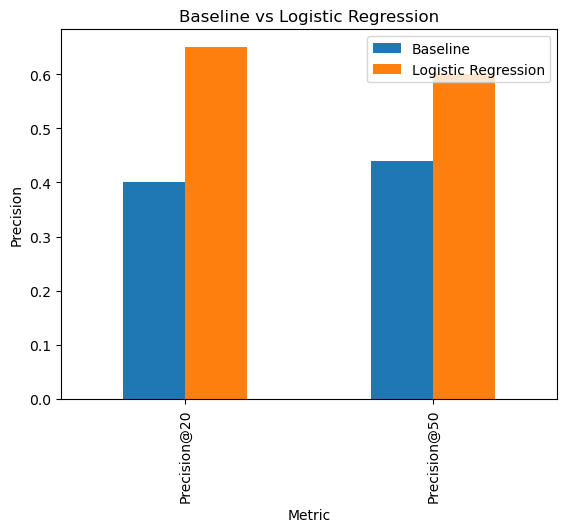

In [26]:
import matplotlib.pyplot as plt

results_table.set_index(
    "Metric"
).plot(
    kind="bar"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Baseline vs Logistic Regression"
)

plt.show()

## 5. Limitations

*What this work cannot claim.*

This work does not predict future business outcomes or guarantee that refreshing a page will improve its search performance.

The model was trained on an anonymized internship dataset and may not generalize to every website or search environment.

The evaluation focuses on ranking quality using Precision@K rather than measuring the business impact of content updates.

The recommendations should therefore be used as decision support and reviewed by content experts before any action is taken.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final output of the project is a ranked review queue that helps prioritize content pages for manual inspection.

Pages with the highest predicted probability of decline should be reviewed first.

Reason codes such as STALE_HIGH_DEMAND, STALE_VISIBLE, and HIGH_PRIORITY_REFRESH provide additional context for why a page appears in the queue.

The recommended workflow is to:

Review the highest-ranked pages.
Validate the recommendation using editorial expertise.
Refresh content where appropriate.
Continue monitoring search performance after updates.

The model is intended to support, not replace, human decision-making.

In [27]:
ranked_queue = test_results.copy()

ranked_queue["rank"] = (
    ranked_queue["model_score"]
    .rank(
        ascending=False,
        method="first"
    )
)

ranked_queue = ranked_queue.sort_values(
    "rank"
)

ranked_queue.head(20)

,search_volume,impressions_90d,ctr,avg_position,word_count,content_age_days,days_since_last_update,competition,model_score,actual,rank
10449,20.0,2,0.00,5.0,4074.0,127,104,0.84,0.738860,1,1.0
22336,20.0,14,0.00,10.1,3713.0,127,104,0.89,0.735560,1,2.0
24114,30.0,4,0.00,17.5,4228.0,127,104,0.34,0.727693,1,3.0
2754,14800.0,122,0.00,7.1,2875.0,106,89,0.36,0.726450,1,4.0
4213,10.0,1620,0.06,1.1,2869.0,106,106,0.21,0.726398,1,5.0
22204,30.0,6,0.00,4.3,4075.0,127,104,0.16,0.724424,0,6.0
6140,10.0,384,0.26,7.6,2818.0,105,89,1.00,0.724000,1,7.0
7026,0.0,307,0.00,4.9,2911.0,106,106,0.00,0.723525,1,8.0
19965,10.0,139,0.00,13.9,2712.0,105,89,0.90,0.722638,0,9.0
27993,0.0,1266,0.00,4.6,2849.0,106,106,0.00,0.722001,0,10.0


In [28]:
def assign_reason(row):
    if row["days_since_last_update"] > 365:
        return "STALE_HIGH_DEMAND"
    elif row["impressions_90d"] > 0:
        return "STALE_VISIBLE"
    else:
        return "HIGH_PRIORITY_REFRESH"


ranked_queue["reason_code"] = (
    ranked_queue.apply(
        assign_reason,
        axis=1
    )
)

ranked_queue.head()

,search_volume,impressions_90d,ctr,avg_position,word_count,content_age_days,days_since_last_update,competition,model_score,actual,rank,reason_code
10449,20.0,2,0.00,5.0,4074.0,127,104,0.84,0.738860,1,1.0,STALE_VISIBLE
22336,20.0,14,0.00,10.1,3713.0,127,104,0.89,0.735560,1,2.0,STALE_VISIBLE
24114,30.0,4,0.00,17.5,4228.0,127,104,0.34,0.727693,1,3.0,STALE_VISIBLE
2754,14800.0,122,0.00,7.1,2875.0,106,89,0.36,0.726450,1,4.0,STALE_VISIBLE
4213,10.0,1620,0.06,1.1,2869.0,106,106,0.21,0.726398,1,5.0,STALE_VISIBLE


In [29]:
ranked_queue.to_csv(
    "../outputs/refresh_queue_sample.csv",
    index=False
)

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper includes the following supporting artifacts:

Dataset overview table
Class distribution summary
Baseline versus model performance table
Precision@20 and Precision@50 comparison chart
Logistic Regression feature importance chart
Ranked recommendation sample
Action playbook example
Links to the project notebooks and repository for reproducibility

These artifacts provide evidence for the reported findings and document the complete workflow from data preparation through evaluation and recommendation generation.

In [31]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "weight": model.named_steps["classifier"].coef_[0]
})

feature_importance = feature_importance.sort_values(
    "weight",
    ascending=False
)

feature_importance

,feature,weight
7,competition,0.109109
6,days_since_last_update,0.005237
4,word_count,0.000050
0,search_volume,0.000005
1,impressions_90d,-0.000005
3,avg_position,-0.000828
5,content_age_days,-0.003015
2,ctr,-0.051779


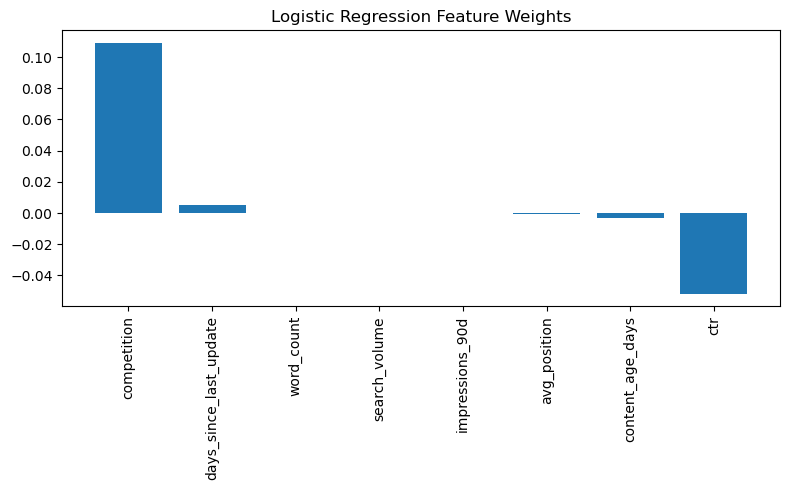

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["feature"],
    feature_importance["weight"]
)

plt.xticks(
    rotation=90
)

plt.title(
    "Logistic Regression Feature Weights"
)

plt.tight_layout()

plt.savefig(
    "../outputs/feature_importance.png"
)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
